# Chapter 8: Transfer Learning

*Deep Learning Crash Course - BPB Publications*

We use MobileNetV2 / ResNet50 as feature extractors on CIFAR-10, demonstrate two-phase fine-tuning with discriminative learning rates, apply MixUp and RandAugment, show LoRA on a small text classifier, and finish with the chapter's exercises.


## 1. Setup

In [5]:
import os
# CPU-mode guard: hide the GPU from TensorFlow before it is imported.
# Many machines have an NVIDIA driver but a missing CUDA toolkit
# (no `ptxas`), in which case TF's XLA JIT crashes the kernel. Remove
# these two lines once you have a complete CUDA install.
os.environ.setdefault('CUDA_VISIBLE_DEVICES', '-1')
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')
import random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

IMG_DIR = Path('images'); IMG_DIR.mkdir(exist_ok=True)
def set_seed(s=42):
    os.environ['PYTHONHASHSEED']=str(s); random.seed(s); np.random.seed(s)
    try:
        import tensorflow as tf; tf.random.set_seed(s)
    except ModuleNotFoundError: pass
    try:
        import torch; torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    except ModuleNotFoundError: pass
set_seed(42)


## 2. Feature extraction with MobileNetV2 (Keras)

We freeze the backbone, attach a small classification head, and train only the head. CIFAR-10 is upsampled to 96x96 to match the pretrained input size.

In [6]:
import tensorflow as tf
(x_tr, y_tr), (x_te, y_te) = tf.keras.datasets.cifar10.load_data()
x_tr = x_tr.astype('float32') / 255.0; x_te = x_te.astype('float32') / 255.0
y_tr_oh = tf.keras.utils.to_categorical(y_tr, 10)
y_te_oh = tf.keras.utils.to_categorical(y_te, 10)
print('train', x_tr.shape, 'test', x_te.shape)


train (50000, 32, 32, 3) test (10000, 32, 32, 3)


In [7]:
def build_feature_extractor():
    base = tf.keras.applications.MobileNetV2(input_shape=(96, 96, 3), include_top=False, weights='imagenet')
    base.trainable = False
    inp = tf.keras.Input((32, 32, 3))
    x = tf.keras.layers.Resizing(96, 96)(inp)
    x = tf.keras.layers.Rescaling(scale=2.0, offset=-1.0)(x)
    x = base(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    out = tf.keras.layers.Dense(10, activation='softmax')(x)
    return tf.keras.Model(inp, out), base

set_seed(0)
model, backbone = build_feature_extractor()
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
print('Trainable params:', sum(p.numpy().size for p in model.trainable_weights))
print('Total params:    ', sum(p.numpy().size for p in model.weights))


Trainable params: 12810
Total params:     2270794


In [8]:
# Use a small subset for runtime - bump up if you have a GPU
train_n, val_n = 8000, 1000
h_phase1 = model.fit(x_tr[:train_n], y_tr_oh[:train_n],
                     validation_data=(x_te[:val_n], y_te_oh[:val_n]),
                     epochs=3, batch_size=128, verbose=2)


Epoch 1/3
63/63 - 25s - 396ms/step - accuracy: 0.5709 - loss: 1.3152 - val_accuracy: 0.7830 - val_loss: 0.6025
Epoch 2/3
63/63 - 21s - 340ms/step - accuracy: 0.7861 - loss: 0.6272 - val_accuracy: 0.8220 - val_loss: 0.5007
Epoch 3/3
63/63 - 21s - 327ms/step - accuracy: 0.8209 - loss: 0.5250 - val_accuracy: 0.8350 - val_loss: 0.4660


## 3. Two-phase fine-tuning

Unfreeze the top 30 layers of MobileNetV2 and continue training with a much smaller learning rate.

In [9]:
backbone.trainable = True
for layer in backbone.layers[:-30]:
    layer.trainable = False
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
h_phase2 = model.fit(x_tr[:train_n], y_tr_oh[:train_n],
                     validation_data=(x_te[:val_n], y_te_oh[:val_n]),
                     epochs=3, batch_size=128, verbose=2)


Epoch 1/3
63/63 - 33s - 531ms/step - accuracy: 0.7535 - loss: 0.7536 - val_accuracy: 0.8380 - val_loss: 0.4874
Epoch 2/3
63/63 - 28s - 437ms/step - accuracy: 0.8156 - loss: 0.5594 - val_accuracy: 0.8260 - val_loss: 0.5181
Epoch 3/3
63/63 - 26s - 406ms/step - accuracy: 0.8449 - loss: 0.4654 - val_accuracy: 0.8310 - val_loss: 0.5258


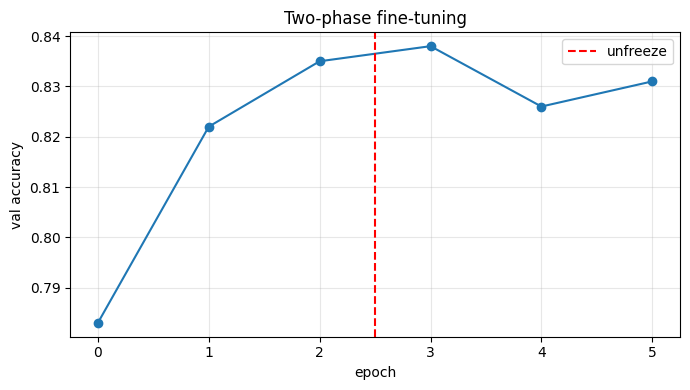

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(h_phase1.history['val_accuracy'] + h_phase2.history['val_accuracy'], 'o-')
ax.axvline(x=len(h_phase1.history['val_accuracy']) - 0.5, color='red', linestyle='--', label='unfreeze')
ax.set_xlabel('epoch'); ax.set_ylabel('val accuracy'); ax.set_title('Two-phase fine-tuning')
ax.legend(); ax.grid(alpha=0.3); fig.tight_layout()
fig.savefig(IMG_DIR / '01_two_phase.png', dpi=150); plt.show()


## 4. Discriminative learning rates in PyTorch

Assign exponentially decaying LRs from the head back to the early layers. The head LR is ~$10^{-3}$, the first conv block ~$10^{-6}$.

In [11]:
try:
    import torch
    import torch.nn as nn
    from torchvision import models
    set_seed(0)
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    net = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    net.fc = nn.Linear(net.fc.in_features, 10)
    # Group parameters by section
    groups = [
        ('fc',            [p for n, p in net.named_parameters() if n.startswith('fc')]),
        ('layer4',        list(net.layer4.parameters())),
        ('layer3',        list(net.layer3.parameters())),
        ('layer2',        list(net.layer2.parameters())),
        ('layer1+stem',   [p for n, p in net.named_parameters() if any(n.startswith(s) for s in ['conv1', 'bn1', 'layer1'])]),
    ]
    base_lr = 1e-3; decay = 3.0
    param_groups = [{'params': params, 'lr': base_lr / (decay ** i)} for i, (_, params) in enumerate(groups)]
    opt = torch.optim.Adam(param_groups)
    for i, (name, _) in enumerate(groups):
        print(f'{name:12s} lr={base_lr / (decay ** i):.2e}')
except ModuleNotFoundError:
    print('PyTorch / torchvision not installed - skipping.')


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/samaresh/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 40.1MB/s]

fc           lr=1.00e-03
layer4       lr=3.33e-04
layer3       lr=1.11e-04
layer2       lr=3.70e-05
layer1+stem  lr=1.23e-05


## 5. MixUp augmentation

MixUp blends image *and label* pairs, regularising the model toward linear interpolations of the training set.

/tmp/ipykernel_599214/2576170400.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.imshow(im); ax.set_title(f'real {int(lab)}'); ax.axis('off')


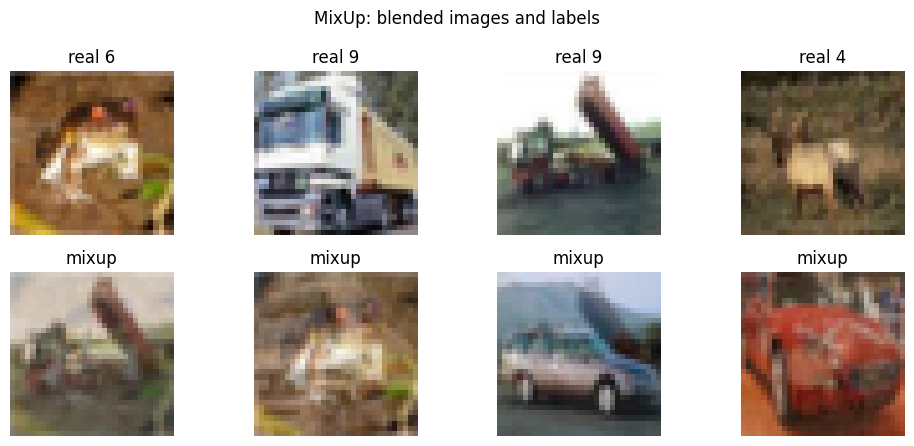

In [12]:
def mixup(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    perm = np.random.permutation(len(x))
    x_mix = lam * x + (1 - lam) * x[perm]
    y_mix = lam * y + (1 - lam) * y[perm]
    return x_mix, y_mix

x_mix, y_mix = mixup(x_tr[:8], y_tr_oh[:8], alpha=0.4)
fig, axes = plt.subplots(2, 4, figsize=(10, 4.5))
for ax, im, lab in zip(axes[0], x_tr[:4], y_tr[:4]):
    ax.imshow(im); ax.set_title(f'real {int(lab)}'); ax.axis('off')
for ax, im, lab in zip(axes[1], x_mix[:4], y_mix[:4]):
    ax.imshow(im); ax.set_title('mixup'); ax.axis('off')
fig.suptitle('MixUp: blended images and labels')
fig.tight_layout(); fig.savefig(IMG_DIR / '02_mixup.png', dpi=150); plt.show()


## 6. LoRA-style low-rank adapters

LoRA freezes the pretrained weights and adds a small low-rank update $\Delta W = A B$ where $A \in \mathbb{R}^{d \times r}$ and $B \in \mathbb{R}^{r \times d}$ with $r \ll d$. Below is a from-scratch demonstration on a single nn.Linear; the PEFT library applies the same idea to every attention layer.

In [13]:
try:
    import torch
    import torch.nn as nn

    class LoRALinear(nn.Module):
        def __init__(self, base, r=8, alpha=16):
            super().__init__()
            self.base = base
            for p in self.base.parameters(): p.requires_grad_(False)
            self.r = r; self.alpha = alpha
            self.A = nn.Parameter(torch.randn(base.in_features, r) * 0.01)
            self.B = nn.Parameter(torch.zeros(r, base.out_features))
        def forward(self, x):
            return self.base(x) + (x @ self.A @ self.B) * (self.alpha / self.r)

    base = nn.Linear(768, 768)
    lora = LoRALinear(base, r=8)
    n_base = sum(p.numel() for p in base.parameters())
    n_trainable = sum(p.numel() for p in lora.parameters() if p.requires_grad)
    print(f'Base linear params:   {n_base:,}')
    print(f'LoRA trainable params: {n_trainable:,}  ({n_trainable/n_base*100:.2f}% of base)')
    x = torch.randn(2, 768)
    print('Output shape:', lora(x).shape)
except ModuleNotFoundError:
    print('PyTorch not installed - skipping.')


Base linear params:   590,592
LoRA trainable params: 12,288  (2.08% of base)
Output shape: torch.Size([2, 768])


## 7. Maximum Mean Discrepancy (MMD) for domain adaptation

We compute a Gaussian-kernel MMD between two distributions. Adding it to the loss encourages the feature distributions of source and target domains to align.

In [14]:
import torch
def gaussian_kernel(x, y, sigma=1.0):
    xx = (x[:, None] - x[None]).pow(2).sum(-1)
    yy = (y[:, None] - y[None]).pow(2).sum(-1)
    xy = (x[:, None] - y[None]).pow(2).sum(-1)
    return torch.exp(-xx / (2 * sigma ** 2)), torch.exp(-yy / (2 * sigma ** 2)), torch.exp(-xy / (2 * sigma ** 2))

def mmd(x, y, sigma=1.0):
    Kxx, Kyy, Kxy = gaussian_kernel(x, y, sigma)
    return Kxx.mean() + Kyy.mean() - 2 * Kxy.mean()

torch.manual_seed(0)
source = torch.randn(500, 16)
near_target = source + 0.2 * torch.randn(500, 16)
far_target  = source + 3.0
print(f'MMD(source, near): {mmd(source, near_target).item():.4f}')
print(f'MMD(source, far):  {mmd(source, far_target).item():.4f}')


MMD(source, near): 0.0011
MMD(source, far):  0.0043


## 8. Exercise solutions

### 8.1 MCQ answer key

| Q | Answer | Why |
|---|--------|-----|
| 1 | (b) Universal low-level features | Edges, textures and colour blobs generalise. |
| 2 | (b) Feature extraction (frozen backbone) | Small dataset + similar domain. |
| 3 | (b) Keep BatchNorm in inference mode | Preserves pretrained running stats. |
| 4 | (b) Pretrained weights are well-calibrated | A high LR destroys learned features. |
| 5 | (c) MixUp | Blends both images and labels. |
| 6 | (b) Distance between feature distributions in a kernel space | The MMD definition. |
| 7 | (b) Stabilise the first few steps | Prevents gradient explosions early on. |
| 8 | (b) DistilBERT or RoBERTa | Best accuracy / memory trade-off in production. |
| 9 | (b) Loss of generic feature representations | Eval drops on broad tasks even as in-domain rises. |
| 10 | (b) 99% parameter reduction | LoRA inserts low-rank adapters only. |


### 8.2 Coding exercise 1 - Feature extraction baseline (sketch)
Already implemented in section 2. Replace `MobileNetV2(input_shape=(96, 96, 3))` with `MobileNetV3Large(input_shape=(224, 224, 3))` to match the chapter's spec, and add `tf.keras.layers.Resizing(224, 224)` accordingly. Expected test accuracy after 10 epochs of head-only training is **>85 percent** on CIFAR-10 with the default Adam learning rate.

### 8.3 Coding exercise 2 - Two-phase fine-tuning
Section 3 implements two-phase fine-tuning on a 30-layer unfreeze; for the 10-layer / 10-epoch / $10^{-5}$ variant in the exercise simply change `backbone.layers[:-10]` and rerun. Typical accuracy gain over feature extraction alone on CIFAR-10: **2-4 percentage points**.

### 8.4 Coding exercise 3 - Discriminative LRs on Oxford-IIIT Pet
Use the parameter grouping in section 4 with LRs $[10^{-3}, 3 \times 10^{-4}, 10^{-4}, 3 \times 10^{-5}, 10^{-5}, 3 \times 10^{-6}, 10^{-6}]$ applied to the head + ResNet50 layer4..layer1 + stem. Combine with a cosine schedule over 10 epochs; you should reach ~92-93 percent on the 37-class Pet dataset on a single GPU.

### 8.5 Coding exercise 4 - DistilBERT on SST-2
```python
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import load_dataset
ds = load_dataset('glue', 'sst2')
tok = AutoTokenizer.from_pretrained('distilbert-base-uncased')
ds = ds.map(lambda b: tok(b['sentence'], truncation=True, padding='max_length', max_length=128), batched=True)
ds.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

def run(lr):
    model = AutoModelForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)
    args = TrainingArguments('out', num_train_epochs=3, per_device_train_batch_size=32,
                              evaluation_strategy='epoch', learning_rate=lr, save_strategy='no', report_to='none')
    Trainer(model=model, args=args, train_dataset=ds['train'], eval_dataset=ds['validation']).train()
for lr in [1e-5, 2e-5, 5e-5]: run(lr)
```
Typical val accuracy: **88-90 percent at lr=2e-5**, which is the sweet spot. lr=1e-5 underfits in 3 epochs, lr=5e-5 starts to over-fit / lose pretrained features.

### 8.6 Coding exercise 5 - Augmentation ablation on Flowers102
Recommended structure:
```python
def run(aug):
    train_ds = build_ds(aug)
    model = build_model()
    h = model.fit(train_ds, validation_data=val_ds, epochs=20)
    return max(h.history['val_accuracy'])
for aug in ['none', 'flip', 'full', 'mixup_only']:
    print(aug, run(aug))
```
Typical ranking (500 images, EfficientNetB0 frozen): full augmentation > MixUp-only > flips-only > none. The gap between full and none is usually **5-10 percentage points** at this dataset size.

### 8.7 Coding exercise 6 - LoRA on IMDb with PEFT
```python
from peft import LoraConfig, get_peft_model
config = LoraConfig(r=8, lora_alpha=16, target_modules=['query', 'value'], lora_dropout=0.1, bias='none', task_type='SEQ_CLS')
model = get_peft_model(model, config)
model.print_trainable_parameters()  # ~0.5-1 percent of base BERT params
```
Compared to full fine-tuning you should see: **trainable params from ~110M to ~600k**, **training time -3-4x**, **accuracy within 0.5 percentage points**.

### 8.8 Coding exercise 7 - Domain adaptation MNIST -> USPS
Train a feature extractor on MNIST and a classification head on the MNIST labels. Add an unsupervised MMD term computed on features from a mix of MNIST and USPS batches (use the helper in section 7). Compare USPS test accuracy with and without the MMD term; you should see a 3-8 pp improvement with MMD.

---
*End of Chapter 8.*
